In [1]:
import pandas as pd
import seaborn as sns 

In [2]:
marco_counts = pd.read_csv('../data/Marco-count-table.csv', sep='\t')
marco_counts['OTU'] = marco_counts['OTU'].apply(lambda x: x.split(' ')[0] + ' ' + x.split(' ')[1])

In [3]:
marco_counts.query('lib == "PV064"')

,OTU,lib,taxon,site,habitat,count
1525,Arthrobacter sp.,PV064,Artemisia_herba_alba,E1,waste,94
1526,Aureimonas sp.,PV064,Artemisia_herba_alba,E1,waste,16
1527,Caulobacter zeae,PV064,Artemisia_herba_alba,E1,waste,2
1528,Cellulomonas sp.,PV064,Artemisia_herba_alba,E1,waste,4
1529,Cupriavidus gilardii,PV064,Artemisia_herba_alba,E1,waste,28
1530,Duganella sp.,PV064,Artemisia_herba_alba,E1,waste,1494
1531,Dyadobacter endophyticus,PV064,Artemisia_herba_alba,E1,waste,774
1532,Ensifer shofinae,PV064,Artemisia_herba_alba,E1,waste,576
1533,Epibacterium ulvae,PV064,Artemisia_herba_alba,E1,waste,2
1534,Frigoribacterium endophyticum,PV064,Artemisia_herba_alba,E1,waste,6


In [33]:
marco_otus_bylibrary = marco_counts.value_counts(subset=['lib']).reset_index().rename(columns={'lib': 'library', 0: 'OTUs'})

In [34]:
hits = pd.read_json('../results/marco-mapping-2025-02-25/PV064_21351_GCCAAT.species.json')
hits[:10]

,species_name,taxid,count,library
0,Aureimonas sp.,1872658,6054,PV064
1,Microbacterium barkeri,33917,4943,PV064
2,Sphingomonas sp.,28214,1054,PV064
3,Duganella sp.,1904440,1044,PV064
4,Candidatus Phytoplasma,33926,680,PV064
5,Arthrobacter sp.,1667,340,PV064
6,Pelomonas sp.,1971397,250,PV064
7,Frigoribacterium sp.,1880915,212,PV064
8,Massilia sp.,1882437,167,PV064
9,Methylobacterium sp.,409,141,PV064


In [35]:
hits

,species_name,taxid,count,library
0,Aureimonas sp.,1872658,6054,PV064
1,Microbacterium barkeri,33917,4943,PV064
2,Sphingomonas sp.,28214,1054,PV064
3,Duganella sp.,1904440,1044,PV064
4,Candidatus Phytoplasma,33926,680,PV064
...,...,...,...,...
105,Methylobacterium pseudosasicola,582667,1,PV064
106,Curtobacterium sp.,1869344,1,PV064
107,Rhodococcus fascians,1828,1,PV064
108,Curtobacterium luteum,33881,1,PV064


In [19]:
marco_counts.query('lib == "PV064"')

,OTU,lib,taxon,site,habitat,count
1525,Arthrobacter sp.,PV064,Artemisia_herba_alba,E1,waste,94
1526,Aureimonas sp.,PV064,Artemisia_herba_alba,E1,waste,16
1527,Caulobacter zeae,PV064,Artemisia_herba_alba,E1,waste,2
1528,Cellulomonas sp.,PV064,Artemisia_herba_alba,E1,waste,4
1529,Cupriavidus gilardii,PV064,Artemisia_herba_alba,E1,waste,28
1530,Duganella sp.,PV064,Artemisia_herba_alba,E1,waste,1494
1531,Dyadobacter endophyticus,PV064,Artemisia_herba_alba,E1,waste,774
1532,Ensifer shofinae,PV064,Artemisia_herba_alba,E1,waste,576
1533,Epibacterium ulvae,PV064,Artemisia_herba_alba,E1,waste,2
1534,Frigoribacterium endophyticum,PV064,Artemisia_herba_alba,E1,waste,6


In [20]:
pd.merge(hits, marco_counts.query('lib == "PV064"'), how='inner', right_on='OTU', left_on='species_name')

,species_name,taxid,count_x,library,OTU,lib,taxon,site,habitat,count_y
0,Aureimonas sp.,1872658,6054,PV064,Aureimonas sp.,PV064,Artemisia_herba_alba,E1,waste,16
1,Microbacterium barkeri,33917,4943,PV064,Microbacterium barkeri,PV064,Artemisia_herba_alba,E1,waste,4248
2,Duganella sp.,1904440,1044,PV064,Duganella sp.,PV064,Artemisia_herba_alba,E1,waste,1494
3,Arthrobacter sp.,1667,340,PV064,Arthrobacter sp.,PV064,Artemisia_herba_alba,E1,waste,94
4,Neoasaia chiangmaiensis,320497,100,PV064,Neoasaia chiangmaiensis,PV064,Artemisia_herba_alba,E1,waste,2
5,Sphingomonas panacis,1560345,26,PV064,Sphingomonas panacis,PV064,Artemisia_herba_alba,E1,waste,2
6,Pseudomonas lutea,243924,25,PV064,Pseudomonas lutea,PV064,Artemisia_herba_alba,E1,waste,6
7,Nocardioides sp.,35761,23,PV064,Nocardioides sp.,PV064,Artemisia_herba_alba,E1,waste,4
8,Rathayibacter tritici,33888,8,PV064,Rathayibacter tritici,PV064,Artemisia_herba_alba,E1,waste,2
9,Cellulomonas sp.,40001,6,PV064,Cellulomonas sp.,PV064,Artemisia_herba_alba,E1,waste,4


## Debugging (2025-03-03)

In [13]:
import pandas as pd

In [14]:
sanchis21 = pd.read_csv("../data/sanchis2021.sup_file_1.csv", sep=';')
sanchis21[:10]

,TaxId,Biosample,Representative species,patho,symb
0,178901,SAMN02849420,Acetobacter malorum,NaN,NaN
1,441768,SAMN02603756,Acholeplasma laidlawii PG-8A,NaN,NaN
2,32002,SAMN06198582,Achromobacter denitrificans,NaN,NaN
3,217204,SAMN06174288,Achromobacter insolitus,NaN,NaN
4,72556,SAMN03941583,Achromobacter piechaudii,NaN,NaN
5,1156919,SAMN01083790,Achromobacter piechaudii HLE,NaN,NaN
6,1397275,SAMN02729851,Achromobacter sp. DH1f,NaN,NaN
7,1736602,SAMN04155871,Achromobacter sp. Root83,NaN,NaN
8,85698,SAMN03996290,Achromobacter xylosoxidans,NaN,NaN
9,85698,SAMN04482112,Achromobacter xylosoxidans,NaN,NaN


In [15]:
marco_counts['OTU'].isin(sanchis21['Representative species']).value_counts()

True     6112
False    5121
Name: OTU, dtype: int64

In [16]:
hits['species name'].isin(sanchis21['Representative species']).value_counts()

True     415
False    172
Name: species name, dtype: int64

In [22]:
import requests
def get_taxid(name):
    r = requests.get(f"https://api.ncbi.nlm.nih.gov/datasets/v2/taxonomy/taxon/{name}")
    try:
        r.raise_for_status()
        data = r.json()
    except requests.HTTPError:
        print(f"-- taxon {name}, not found")
        return None
    return data['taxonomy_nodes'][0]['taxonomy']['tax_id']

In [23]:
# hits_pv064 = hits.query('library == "PV064"').copy()
reference_pv064 = marco_counts.query('lib == "PV064"').copy()

In [24]:
# hits_pv064['tax-id'] = hits_pv064['species name'].apply(get_taxid)
reference_pv064['tax-id'] = reference_pv064['OTU'].apply(get_taxid)

In [15]:
hits[['taxid']]

,taxid
0,1672749
1,33926
2,1549858
3,223967
4,1560345
...,...
78,216778
79,85558
80,582667
81,29447


In [26]:
matches = pd.merge(hits, reference_pv064, left_on='taxid', right_on='tax-id')

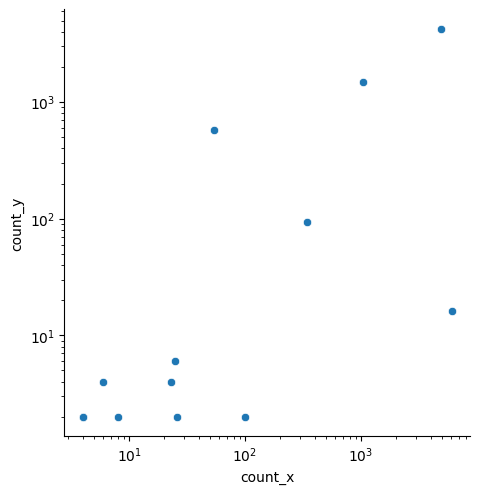

In [29]:
g = sns.relplot(matches, x='count_x', y='count_y')
g.axes[0, 0].set_xscale('log')
g.axes[0, 0].set_yscale('log')